# Spaceship Titanic Classification with ML

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Preprocessing
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
train.shape, test.shape

((8693, 14), (4277, 13))

In [4]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [6]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [7]:
df=pd.concat([train,test]) 

## EDA

In [8]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  object 
 1   HomePlanet    12682 non-null  object 
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  object 
 4   Destination   12696 non-null  object 
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  object 
 13  Transported   8693 non-null   object 
dtypes: float64(6), object(8)
memory usage: 1.5+ MB


In [10]:
df.isnull().sum()

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
Transported     4277
dtype: int64

In [11]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,12700.000000,12707.000000,12681.000000,12664.000000,12686.000000,12702.000000
mean,28.771969,222.897852,451.961675,174.906033,308.476904,306.789482
std,14.387261,647.596664,1584.370747,590.558690,1130.279641,1180.097223
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,49.000000,77.000000,29.000000,57.000000,42.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## Data Processing & Feature Engineering

In [12]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [13]:
df['Transported'] = df['Transported'].map({False: 1, True: 0})

In [14]:
df.CryoSleep.value_counts()

CryoSleep
False    8079
True     4581
Name: count, dtype: int64

In [15]:
df.VIP.value_counts()

VIP
False    12401
True       273
Name: count, dtype: int64

In [16]:
df['CryoSleep'] = df['CryoSleep'].map({False: 1, True: 0})

In [17]:
df['VIP'] = df['VIP'].map({False: 1, True: 0})

In [18]:
df['CryoSleep'].fillna(df['CryoSleep'].mode()[0], inplace=True)

In [19]:
df['VIP'].fillna(df['VIP'].mode()[0], inplace=True)

In [20]:
df['HomePlanet'].fillna(df['HomePlanet'].mode()[0], inplace=True)

In [21]:
df['Destination'].fillna(df['Destination'].mode()[0], inplace=True)

In [22]:
df['Age'].fillna(df['Age'].median(), inplace=True)

In [23]:
df['RoomService'].fillna(0, inplace=True)

In [24]:
df['FoodCourt'].fillna(0, inplace=True)

In [25]:
df['ShoppingMall'].fillna(0, inplace=True)

In [26]:
df['Spa'].fillna(0, inplace=True)

In [27]:
df['VRDeck'].fillna(0, inplace=True)

In [28]:
df.isnull().sum()

PassengerId        0
HomePlanet         0
CryoSleep          0
Cabin            299
Destination        0
Age                0
VIP                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Name             294
Transported     4277
dtype: int64

In [29]:
df.Cabin.value_counts()

Cabin
G/734/S     8
G/160/P     8
B/11/S      7
G/109/P     7
C/137/S     7
           ..
F/0/P       1
F/1/S       1
B/0/P       1
E/591/P     1
F/1790/S    1
Name: count, Length: 9825, dtype: int64

In [30]:
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

In [31]:
df['Group'] = df['PassengerId'].str.split('_').str[0]

In [32]:
df['Deck'] = df.groupby('Group')['Deck'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

df['Deck'] = df['Deck'].fillna('Unknown')

In [33]:
df['Side'] = df.groupby('Group')['Side'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

df['Side'] = df['Side'].fillna(df['Side'].mode()[0])

In [34]:
df['Num'] = pd.to_numeric(df['Num'], errors='coerce')

In [35]:
df['Num'] = df.groupby(['Group','Deck'])['Num'].transform(lambda x: x.fillna(x.median()))

In [36]:
df['Num'] = df['Num'].fillna(df['Num'].median())

In [37]:
df.isnull().sum()

PassengerId        0
HomePlanet         0
CryoSleep          0
Cabin            299
Destination        0
Age                0
VIP                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Name             294
Transported     4277
Deck               0
Num                0
Side               0
Group              0
dtype: int64

In [38]:
df = df.drop(columns=['Cabin','Name'])

In [39]:
df.isnull().sum()

PassengerId        0
HomePlanet         0
CryoSleep          0
Destination        0
Age                0
VIP                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Transported     4277
Deck               0
Num                0
Side               0
Group              0
dtype: int64

In [40]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Num,Side,Group
0,0001_01,Europa,1.0,TRAPPIST-1e,39.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,B,0.0,P,0001
1,0002_01,Earth,1.0,TRAPPIST-1e,24.0,1.0,109.0,9.0,25.0,549.0,44.0,0.0,F,0.0,S,0002
2,0003_01,Europa,1.0,TRAPPIST-1e,58.0,0.0,43.0,3576.0,0.0,6715.0,49.0,1.0,A,0.0,S,0003
3,0003_02,Europa,1.0,TRAPPIST-1e,33.0,1.0,0.0,1283.0,371.0,3329.0,193.0,1.0,A,0.0,S,0003
4,0004_01,Earth,1.0,TRAPPIST-1e,16.0,1.0,303.0,70.0,151.0,565.0,2.0,0.0,F,1.0,S,0004


In [41]:
df['Total_Spending'] = df['RoomService'] + df['FoodCourt'] + df['ShoppingMall'] + df['Spa'] + df['VRDeck']
df['Is_Spender'] = (df['Total_Spending'] > 0).astype(int)

<Axes: >

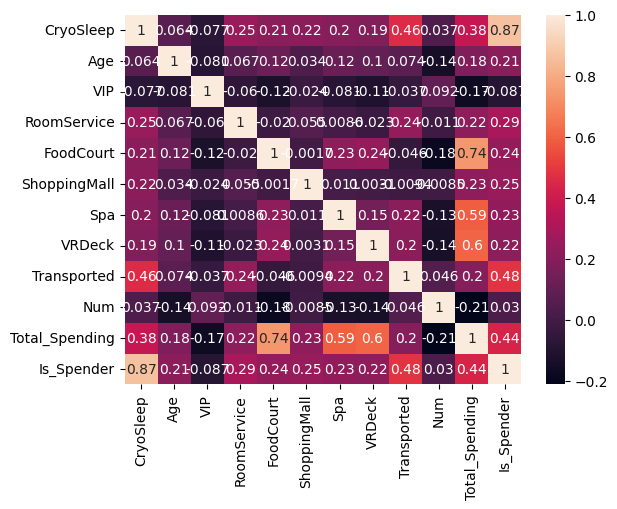

In [42]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Model Training

In [43]:
train = df[df['Transported'].notna()]
test  = df[df['Transported'].isna()]

In [44]:
x = train.drop(['PassengerId', 'Transported','Group'], axis=1)
y = train['Transported']

In [45]:
x_final_test = test.drop(['PassengerId','Transported','Group'], axis=1)

In [46]:
x_all = pd.concat([x, x_final_test])
x_all = pd.get_dummies(x_all, drop_first=True)

In [47]:
x = x_all.iloc[:len(x)]
x_final_test = x_all.iloc[len(x):]

In [48]:
def algo_test(x, y):
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=500, solver='lbfgs'),   
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        MultinomialNB(),
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42),
        LGBMClassifier(verbose=-1, random_state=42),
       
    ]
    isimler = [
        "BernoulliNB", 
        "LogisticRegression", 
        "DecisionTreeClassifier", 
        "RandomForestClassifier", 
        "GradientBoostingClassifier", 
        "KNeighborsClassifier", 
        "AdaBoostClassifier", 
        "MultinomialNB",
        "XGBClassifier",
        "LGBMClassifier"
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    accuracy, precision, recall, f1, mdl = [], [], [], [], []
    
    print("Veriler hazır, modeller deneniyor...")
    for name, model in zip(isimler, modeller):
        print(f"{name} modeli eğitiliyor...")
        if isinstance(model, MultinomialNB):
            if (np.array(x_train) < 0).any():
                print("Uyarı: MultinomialNB negatif değerlerle çalışmaz, bu model atlanıyor!")
                accuracy.append(np.nan)
                precision.append(np.nan)
                recall.append(np.nan)
                f1.append(np.nan)
                mdl.append(None)
                continue
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="binary"))
            recall.append(recall_score(y_test, tahmin, average="binary"))
            f1.append(f1_score(y_test, tahmin, average="binary"))
            print(confusion_matrix(y_test, tahmin))
        except Exception as e:
            print(f"{name} modeli çalıştırılırken hata oluştu: {e}")
            accuracy.append(np.nan)
            precision.append(np.nan)
            recall.append(np.nan)
            f1.append(np.nan)
            mdl.append(None)
    
    print("Eğitim tamamlandı.")
    
    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Model": mdl
    }, index=isimler)

    metrics_sorted = metrics.sort_values("F1", ascending=False)
    
    print("\n" + "="*80)
    print("En başarılı model:", metrics_sorted.dropna().iloc[0].name)
    print("="*80)
    
    en_iyi_model = metrics_sorted.dropna().iloc[0]["Model"]

    tahmin = en_iyi_model.predict(x_test)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("\nClassification Report:")
    print(classification_report(y_test, tahmin))

    print("\n" + "="*80)
    print("TÜM MODELLERİN KARŞILAŞTIRMASI")
    print("="*80)
    print(metrics_sorted.drop("Model", axis=1))

    return metrics_sorted.drop("Model", axis=1)

In [49]:
algo_test(x,y)

Veriler hazır, modeller deneniyor...
BernoulliNB modeli eğitiliyor...
[[591 287]
 [164 697]]
LogisticRegression modeli eğitiliyor...
[[718 160]
 [222 639]]
DecisionTreeClassifier modeli eğitiliyor...
[[673 205]
 [242 619]]
RandomForestClassifier modeli eğitiliyor...
[[679 199]
 [159 702]]
GradientBoostingClassifier modeli eğitiliyor...
[[735 143]
 [211 650]]
KNeighborsClassifier modeli eğitiliyor...
[[688 190]
 [237 624]]
AdaBoostClassifier modeli eğitiliyor...
[[689 189]
 [208 653]]
MultinomialNB modeli eğitiliyor...
[[798  80]
 [349 512]]
XGBClassifier modeli eğitiliyor...
[[700 178]
 [181 680]]
LGBMClassifier modeli eğitiliyor...
[[722 156]
 [175 686]]
Eğitim tamamlandı.

En başarılı model: LGBMClassifier

Confusion Matrix:
[[722 156]
 [175 686]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81       878
         1.0       0.81      0.80      0.81       861

    accuracy                           0.81      173

,Accuracy,Precision,Recall,F1
LGBMClassifier,0.809661,0.814727,0.796748,0.805637
RandomForestClassifier,0.794135,0.779134,0.815331,0.796822
XGBClassifier,0.793560,0.792541,0.789779,0.791158
GradientBoostingClassifier,0.796435,0.819672,0.754936,0.785973
LogisticRegression,0.780334,0.799750,0.742160,0.769880
AdaBoostClassifier,0.771708,0.775534,0.758420,0.766882
BernoulliNB,0.740656,0.708333,0.809524,0.755556
KNeighborsClassifier,0.754457,0.766585,0.724739,0.745075
DecisionTreeClassifier,0.742956,0.751214,0.718931,0.734718
MultinomialNB,0.753306,0.864865,0.594657,0.704749


In [50]:
model= LGBMClassifier()

In [51]:
model.fit(x,y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [52]:
prediction= model.predict(x_final_test)

In [53]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': prediction
})

In [54]:
submission.head()

,PassengerId,Transported
0,0013_01,0.0
1,0018_01,1.0
2,0019_01,0.0
3,0021_01,0.0
4,0023_01,0.0


In [55]:
submission['Transported'] = submission['Transported'].map({1.0: 'False', 0.0: 'True'})

In [56]:
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [57]:
submission.to_csv("submission.csv", index=False)

In [58]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']